part5  CNN

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
#test model
import torch

from models.cnn import FlowerCNN

model = FlowerCNN()

print(model)

FlowerCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [3]:
#Check the output size
dummy = torch.randn(2, 3, 224, 224)

output = model(dummy)

print(output.shape)

torch.Size([2, 102])


In [4]:
from config import DEVICE

model = FlowerCNN().to(DEVICE)

print(DEVICE)

cuda


In [5]:
#Loss
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [6]:
#Optimizer
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003
)

In [7]:
#Learning Rate Scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [8]:
from utils.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders()

In [9]:
#training loop
from utils.train import train_one_epoch, evaluate

num_epochs = 20

train_losses = []
val_losses = []

train_accs = []
val_accs = []

results = []

best_acc = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    results.append({
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc
    })

    print(
        f"Epoch {epoch+1:02d}/{num_epochs}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
    )

    from pathlib import Path

weights_dir = Path("../weights")
weights_dir.mkdir(exist_ok=True)

best_model_path = weights_dir / "best_cnn.pth"

if val_acc > best_acc:

    best_acc = val_acc

    torch.save(model.state_dict(), best_model_path)

    print(f"✅ Best model saved: {best_model_path}")

Epoch 01/20 | Train Loss 4.6062 | Train Acc 0.0245 | Val Loss 4.5106 | Val Acc 0.0294
Epoch 02/20 | Train Loss 4.4476 | Train Acc 0.0353 | Val Loss 4.3338 | Val Acc 0.0598
Epoch 03/20 | Train Loss 4.2840 | Train Acc 0.0529 | Val Loss 4.1861 | Val Acc 0.0745
Epoch 04/20 | Train Loss 4.1601 | Train Acc 0.0471 | Val Loss 4.0533 | Val Acc 0.1088
Epoch 05/20 | Train Loss 4.0041 | Train Acc 0.0716 | Val Loss 3.9614 | Val Acc 0.1147
Epoch 06/20 | Train Loss 3.8892 | Train Acc 0.0745 | Val Loss 3.8577 | Val Acc 0.1353
Epoch 07/20 | Train Loss 3.8623 | Train Acc 0.0794 | Val Loss 3.7771 | Val Acc 0.1608
Epoch 08/20 | Train Loss 3.8369 | Train Acc 0.0755 | Val Loss 3.7489 | Val Acc 0.1608
Epoch 09/20 | Train Loss 3.7382 | Train Acc 0.1020 | Val Loss 3.7097 | Val Acc 0.1647
Epoch 10/20 | Train Loss 3.7425 | Train Acc 0.0951 | Val Loss 3.6999 | Val Acc 0.1627
Epoch 11/20 | Train Loss 3.6983 | Train Acc 0.1049 | Val Loss 3.6421 | Val Acc 0.1775
Epoch 12/20 | Train Loss 3.6702 | Train Acc 0.1010 | V

In [10]:
#save results
from utils.save_results import save_training_results

df = save_training_results(
    results,
    "cnn_results.csv"
)

✅ Results saved to ..\results\cnn_results.csv


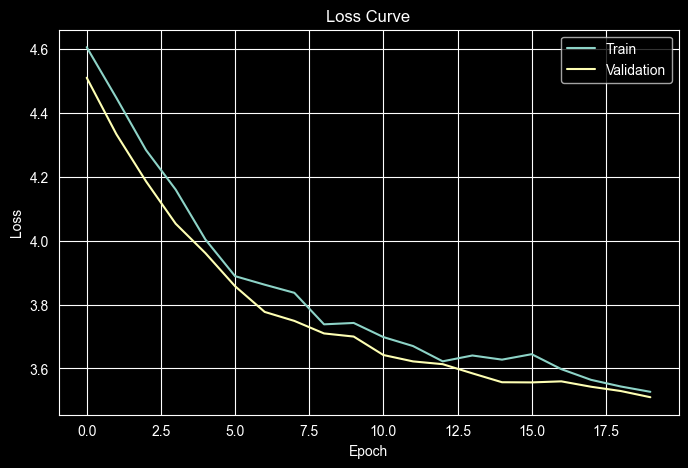

In [11]:
#Loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

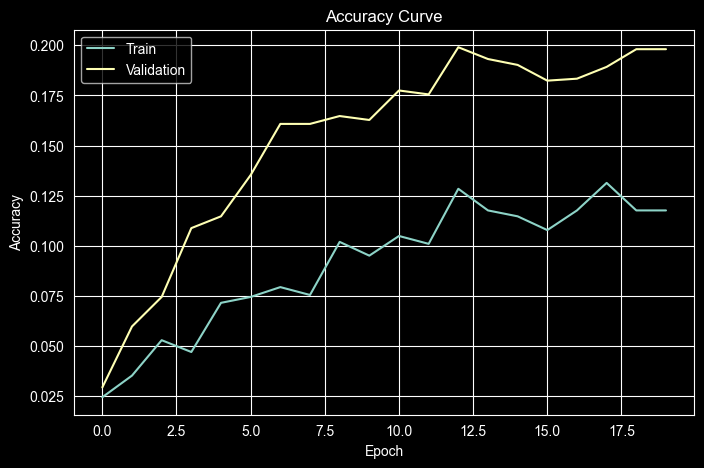

In [12]:
#Accuracy curve
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()